# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: Maya Finkelshtein  Student ID: B00819261
2. Full name: _______________  Student ID: _______________
3. Full name: _______________  Student ID: _______________
4. Full name: _______________  Student ID: _______________

**Group / repo name:** `aidams-lab2-<surname1>-<surname2>-...`  
**Submitter (one person): me
**Repo URL:**  

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel('gem_download/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx', sheet_name="Plant production", na_values=["N/A", "unknown"],) 

In [47]:
file_path = "gem_download/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"

production_df = pd.read_excel(
    file_path,
    sheet_name="Plant production",
    na_values=["N/A", "unknown"],
)

capacities_df = pd.read_excel(
    file_path,
    sheet_name="Plant capacities and status",
    na_values=["N/A", "unknown"],
)

plant_data_df = pd.read_excel(
    file_path,
    sheet_name="Plant data",
    na_values=["N/A", "unknown"],
)

plant_id = "GEM plant ID"

df = (
    production_df
    .merge(plant_data_df[['Workforce size', 'GEM plant ID']], on=plant_id, how="left", suffixes=("", "_plant"))
    .merge(capacities_df, on=plant_id, how="left", suffixes=("", "_capacity"))
)

print(df.shape)
df.head()

(2374, 26)


,GEM plant ID,Plant name (English),Type of production,2019,2020,2021,2022,2023,2024,2025,...,Start date,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal IF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),Nominal iron capacity (ttpa),Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa)
0,P100000120802,Abinsk Electric Steel Works,Crude steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,NaN,...,2014,1600,NaN,1600,NaN,NaN,NaN,NaN,NaN,NaN
1,P100000120802,Abinsk Electric Steel Works,EAF steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,NaN,...,2014,1600,NaN,1600,NaN,NaN,NaN,NaN,NaN,NaN
2,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,NaN,...,NaN,6000,NaN,6000,NaN,NaN,2500,NaN,2500,NaN
3,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,NaN,...,1965,NaN,NaN,NaN,NaN,NaN,3500,3500,NaN,NaN
4,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,NaN,...,1965,7800,7800,NaN,NaN,NaN,4000,4000,NaN,NaN


In [36]:
df.shape

(2374, 26)

In [37]:
df['Type of production'].unique()

array(['Crude steel production (ttpa)', 'EAF steel production (ttpa)',
       'BOF steel production (ttpa)', 'DRI production (ttpa)',
       'Other/Unknown steel production (ttpa)', 'Iron production (ttpa)',
       'BF production (ttpa)', 'Other/Unknown iron production (ttpa)',
       'OHF steel production (ttpa)'], dtype=object)

In [38]:
df.columns 

Index([                           'GEM plant ID',
                          'Plant name (English)',
                            'Type of production',
                                            2019,
                                            2020,
                                            2021,
                                            2022,
                                            2023,
                                            2024,
                                            2025,
                                'Workforce size',
                 'Plant name (English)_capacity',
                   'Plant name (other language)',
                                  'Country/area',
                     'Main production equipment',
                                        'Status',
                                    'Start date',
           'Nominal crude steel capacity (ttpa)',
             'Nominal BOF steel capacity (ttpa)',
             'Nominal EAF steel capacity (ttpa)',


In [39]:


non_na_percentage = (
    df.notna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=True)
      .rename("Non-NA percentage")
)

non_na_percentage

2025                                         1.35
Other/unspecified iron capacity (ttpa)       1.60
Other/unspecified steel capacity (ttpa)      3.20
Nominal IF steel capacity (ttpa)             4.34
Nominal DRI capacity (ttpa)                 17.73
Nominal BOF steel capacity (ttpa)           42.12
Nominal EAF steel capacity (ttpa)           45.96
2019                                        46.80
2024                                        52.27
Nominal BF capacity (ttpa)                  52.86
2021                                        54.84
2023                                        54.89
2020                                        55.18
2022                                        55.86
Plant name (other language)                 58.89
Nominal iron capacity (ttpa)                65.71
Nominal crude steel capacity (ttpa)         84.92
Start date                                  91.91
Workforce size                              94.69
Status                                     100.00


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?


The data for 2025 is basically missing (there is data for only 1.29% of plants which is about 16 plants out of 1400)

For other year, uncluding the furthest year away (2019) only half of the data is available

### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [24]:
import pandera as pa

In [16]:
df.head()

,GEM plant ID,Plant name (English),Type of production,2019,2020,2021,2022,2023,2024,2025
0,P100000120802,Abinsk Electric Steel Works,Crude steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,NaN
1,P100000120802,Abinsk Electric Steel Works,EAF steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,NaN
2,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,NaN
3,P100000120620,Acciaierie d'Italia Taranto steel plant,BOF steel production (ttpa),4300,3400,4100,3800,3000,2000,NaN
4,P100000120634,Acciaierie Venete Borgo Valsugana steel plant,Crude steel production (ttpa),488,475,629,NaN,NaN,NaN,NaN


In [41]:
# Cell written with AI (GPT-5.6 Luna in VSC)

# The raw production columns are object dtype because they contain numeric values
# and markers such as ">0". The 2024 column is used as the target.
required_columns = [
    "GEM plant ID",
    "Type of production",
    'Status',
    'Workforce size',
    'Nominal crude steel capacity (ttpa)',
    2019,
    2020,
    2021,
    2022,
    2023,
    2024,
]

missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

production_columns = required_columns[2:]
production_types = df["Type of production"].dropna().unique().tolist()

def valid_production_value(series):
    numeric_values = pd.to_numeric(series, errors="coerce")
    markers = series.astype("string").str.strip().eq(">0")
    return series.isna() | markers | (numeric_values.notna() & numeric_values.ge(0))

schema_columns = {
    "GEM plant ID": pa.Column(
        object,
        nullable=False,
        checks=pa.Check(lambda s: s.astype("string").str.strip().ne("")),
    ),
    "Type of production": pa.Column(
        object,
        nullable=False,
        checks=pa.Check.isin(production_types),
    ),
}

for column in production_columns:
    schema_columns[column] = pa.Column(
        object,
        nullable=True,
        checks=pa.Check(
            valid_production_value,
            name=f"{column}_nonnegative_or_marker",
        ),
    )

schema = pa.DataFrameSchema(
    schema_columns,
    strict=False,  # Allow other columns, such as 2025, in the raw dataframe
)

try:
    validated_df = schema.validate(df, lazy=True)
    print("Schema validation passed.")
except pa.errors.SchemaErrors as error:
    print("Schema validation failed.")
    display(error.failure_cases)

Schema validation failed.


,schema_context,column,check,check_number,failure_case,index
0,Column,Status,Status_nonnegative_or_marker,0,operating,0
1578,Column,Status,Status_nonnegative_or_marker,0,operating,1578
1580,Column,Status,Status_nonnegative_or_marker,0,operating,1580
1581,Column,Status,Status_nonnegative_or_marker,0,operating,1581
1582,Column,Status,Status_nonnegative_or_marker,0,operating,1582
...,...,...,...,...,...,...
792,Column,Status,Status_nonnegative_or_marker,0,operating,792
793,Column,Status,Status_nonnegative_or_marker,0,operating,793
794,Column,Status,Status_nonnegative_or_marker,0,operating,794
795,Column,Status,Status_nonnegative_or_marker,0,operating,795


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [51]:
# missing values

#removing mostly empy columns
columns_to_remove = [
    2025,
    "Other/unspecified iron capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)",
    "Nominal IF steel capacity (ttpa)",
    "Nominal DRI capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    'Plant name (other language)',
]

df = df.drop(columns=columns_to_remove, errors="ignore")

# substituting na values for mean
capacity_col = "Nominal crude steel capacity (ttpa)"
workforce_col = "Workforce size"
bf_col = "Nominal BF capacity (ttpa)"


df[capacity_col] = pd.to_numeric(df[capacity_col], errors="coerce")
df[workforce_col] = pd.to_numeric(df[workforce_col], errors="coerce")
df[bf_col] = pd.to_numeric(df[bf_col], errors="coerce")

df[capacity_col] = df[capacity_col].fillna(df[capacity_col].mean())
df[workforce_col] = df[workforce_col].fillna(df[workforce_col].mean())
df[bf_col] = df[bf_col].fillna(df[bf_col].mean())

# filling Nominal iron capacity (ttpa) with minimal value accoring to global energy monitor
# for a plant that specializes in iron production, the I will fill values with the mean value, for the rest of the plants, I will fill with 500 since its the minimum value
df["Nominal iron capacity (ttpa)"] = pd.to_numeric(df["Nominal iron capacity (ttpa)"], errors="coerce")
mean_iron = df['Nominal iron capacity (ttpa)'].mean()
df['Nominal iron capacity (ttpa)'] = df.apply(
    lambda row: mean_iron if pd.isna(row['Nominal iron capacity (ttpa)']) and row['Type of production'] == 'Iron production (ttpa)' else (500 if pd.isna(row['Nominal iron capacity (ttpa)']) else row['Nominal iron capacity (ttpa)']),
    axis=1
)
#df["Nominal iron capacity (ttpa)"] = df["Nominal iron capacity (ttpa)"].fillna(500)

df.head()


,GEM plant ID,Plant name (English),Type of production,2019,2020,2021,2022,2023,2024,Workforce size,Plant name (English)_capacity,Plant name (other language),Country/area,Main production equipment,Status,Start date,Nominal crude steel capacity (ttpa),Nominal iron capacity (ttpa),Nominal BF capacity (ttpa)
0,P100000120802,Abinsk Electric Steel Works,Crude steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,4500.0,Abinsk Electric Steel Works,АЭМЗ,Russia,EAF,operating,2014,1600.000000,500.0,3502.587952
1,P100000120802,Abinsk Electric Steel Works,EAF steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,4500.0,Abinsk Electric Steel Works,АЭМЗ,Russia,EAF,operating,2014,1600.000000,500.0,3502.587952
2,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,Acciaierie d'Italia Taranto steel plant,NaN,Italy,DRI; EAF,announced,NaN,6000.000000,2500.0,3502.587952
3,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,Acciaierie d'Italia Taranto steel plant,NaN,Italy,BF,retired,1965,2998.537883,3500.0,3500.000000
4,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,Acciaierie d'Italia Taranto steel plant,NaN,Italy,BF; BOF,operating pre-retirement,1965,7800.000000,4000.0,4000.000000


In [82]:
production_years = list(range(2019, 2025))

for year in production_years:
    df[year] = pd.to_numeric(
        df[year].replace(">0", pd.NA),
        errors="coerce"
    ).round().astype("Int64")

df[production_years].dtypes

2019    Int64
2020    Int64
2021    Int64
2022    Int64
2023    Int64
2024    Int64
dtype: object

> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?


Capacity is one of the main factors determining the production. It is crucial for prediction models. so removing them is not an option, I tried to handle missing values in the smart way

### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


New features: steel capacity per worker, age of the plant(years operating)

In [58]:
df["Steel capacity per worker"] = (
    df[capacity_col] / df[workforce_col].replace(0, pd.NA)
)

df[["GEM plant ID", capacity_col, workforce_col, "Steel capacity per worker"]].head()

,GEM plant ID,Nominal crude steel capacity (ttpa),Workforce size,Steel capacity per worker
0,P100000120802,1600.000000,4500.0,0.355556
1,P100000120802,1600.000000,4500.0,0.355556
2,P100000120620,6000.000000,11000.0,0.545455
3,P100000120620,2998.537883,11000.0,0.272594
4,P100000120620,7800.000000,11000.0,0.709091


In [55]:
# Convert start dates/years into a numeric start year.
start_year = pd.to_numeric(df["Start date"], errors="coerce")

date_values = pd.to_datetime(df["Start date"], errors="coerce")
start_year = start_year.fillna(1990)

df["Start date"] = start_year.astype("Int64")

# Calculate plant age using the current year.
reference_year = pd.Timestamp.today().year
df["Years_operating"] = (reference_year - df["Start date"]).clip(lower=0)

df[["Start date", "Years_operating"]].head()

,Start date,Years_operating
0,2014,12
1,2014,12
2,2000,26
3,1965,61
4,1965,61


In [68]:
df['Main production equipment'].unique()

array(['EAF', 'DRI; EAF', 'BF', 'BF; BOF', 'IF', 'BF; BOF; EAF',
       'Steel other/unspecified', 'BF; EAF', 'BOF', 'DRI',
       'BF; Steel other/unspecified', 'BF; BOF; DRI; EAF',
       'BF; DRI; EAF; Iron other/unspecified; Steel other/unspecified',
       'Iron other/unspecified; Steel other/unspecified',
       'DRI; EAF; Iron other/unspecified', 'BF; BOF; DRI',
       'BF; EAF; Steel other/unspecified', 'EAF; IF',
       'BF; BOF; Steel other/unspecified', 'BF; IF', 'BOF; EAF',
       'Iron other/unspecified', 'DRI; IF', 'BF; DRI', 'BF; DRI; IF',
       'DRI; EAF; IF', 'BF; DRI; EAF', 'BF; EAF; IF',
       'BF; DRI; EAF; Steel other/unspecified',
       'BF; BOF; DRI; Steel other/unspecified',
       'BF; BOF; DRI; EAF; Iron other/unspecified',
       'BOF; Iron other/unspecified', 'BF; BOF; DRI; IF',
       'BF; DRI; IF; Steel other/unspecified',
       'BF; BOF; DRI; EAF; IF; Steel other/unspecified'], dtype=object)

In [69]:
equipments = ['EAF', 'BOF', 'DRI', 'IF', 'Other/unspecified', 'BF', 'Iron other/unspecified', 'Steel other/unspecified']

In [66]:
for equipment in equipments:
    df[f"Main_prod_equip_{equipment}"] = (
        df["Main production equipment"]
        .fillna("")
        .str.split(";")
        .apply(lambda values: int(equipment in {value.strip() for value in values}))
    )

df.head()

,GEM plant ID,Plant name (English),Type of production,2019,2020,2021,2022,2023,2024,Workforce size,...,Years_operating,Steel capacity per worker,Main_prod_equip_EAF,Main_prod_equip_BOF,Main_prod_equip_DRI,Main_prod_equip_IF,Main_prod_equip_Other/unspecified,Main_prod_equip_BF,Main_prod_equip_Iron other/unspecified,Main_prod_equip_Steel other/unspecified
0,P100000120802,Abinsk Electric Steel Works,Crude steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,4500.0,...,12,0.355556,1,0,0,0,0,0,0,0
1,P100000120802,Abinsk Electric Steel Works,EAF steel production (ttpa),1500,1400,1600,NaN,NaN,NaN,4500.0,...,12,0.355556,1,0,0,0,0,0,0,0
2,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,...,26,0.545455,1,0,1,0,0,0,0,0
3,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,...,61,0.272594,0,0,0,0,0,1,0,0
4,P100000120620,Acciaierie d'Italia Taranto steel plant,Crude steel production (ttpa),4300,3400,4100,3800,3000,2000,11000.0,...,61,0.709091,0,1,0,0,0,1,0,0


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?


## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


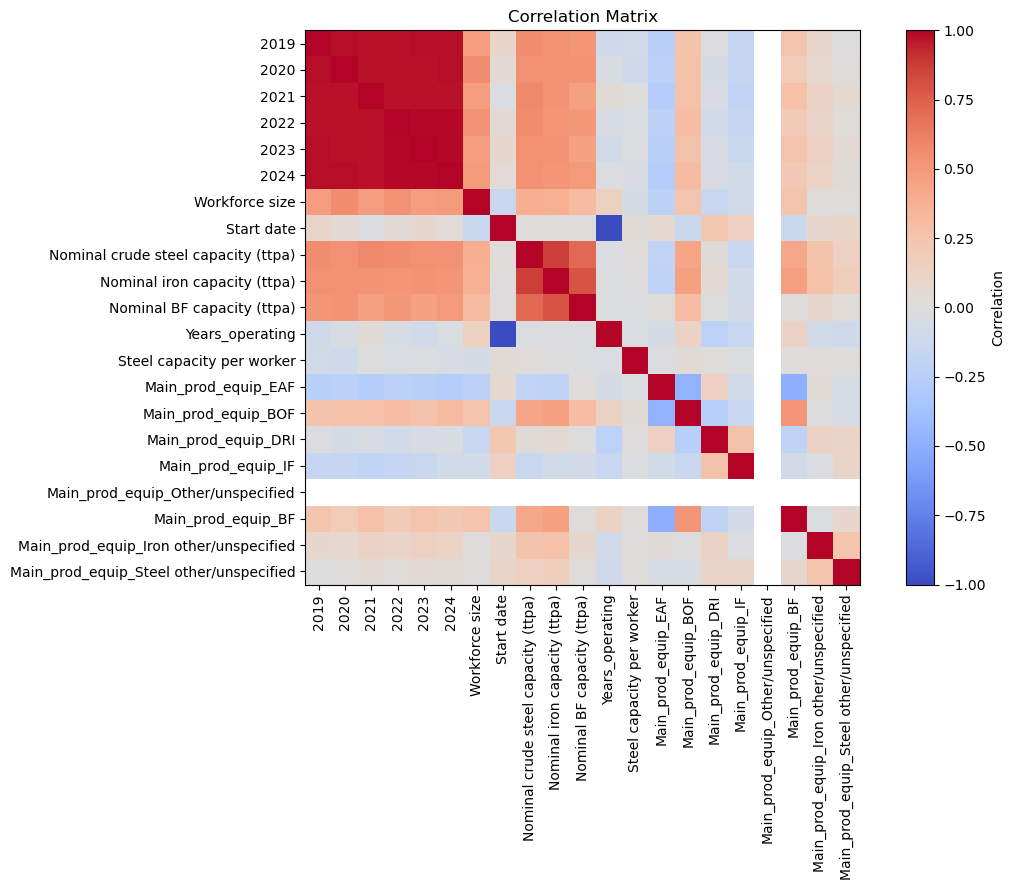

In [71]:
# Convert all non-ID columns to numeric where possible.
# Non-numeric categorical values are converted to NaN and excluded from correlations.
corr_data = (
    df.drop(columns=["GEM plant ID"], errors="ignore")
      .apply(pd.to_numeric, errors="coerce")
      .dropna(axis=1, how="all")
)

correlation_matrix = corr_data.corr()

# display(correlation_matrix)

plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?


- Previous years' production strongly ocrrelates with the next year's production
- nominal capacities correlate with each other (which makes sense, if its a big plant then all of its capacities would be high)
- My hypothesis about use of different equipment correlating with the production didn't justify itself: there is no correlation between variables

In [72]:
df.columns

Index([                           'GEM plant ID',
                          'Plant name (English)',
                            'Type of production',
                                            2019,
                                            2020,
                                            2021,
                                            2022,
                                            2023,
                                            2024,
                                'Workforce size',
                 'Plant name (English)_capacity',
                   'Plant name (other language)',
                                  'Country/area',
                     'Main production equipment',
                                        'Status',
                                    'Start date',
           'Nominal crude steel capacity (ttpa)',
                  'Nominal iron capacity (ttpa)',
                    'Nominal BF capacity (ttpa)',
                               'Years_operating',


In [73]:
columns = [ 'Main production equipment', 'Steel capacity per worker', 'Years_operating', 'Main_prod_equip_EAF',
                           'Main_prod_equip_BOF',
                           'Main_prod_equip_DRI',
                            'Main_prod_equip_IF',
             'Main_prod_equip_Other/unspecified',
                            'Main_prod_equip_BF',
        'Main_prod_equip_Iron other/unspecified',
       'Main_prod_equip_Steel other/unspecified']

df = df.drop(columns=columns_to_remove, errors="ignore")

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [116]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

def root_mean_squared_error(y_true, y_pred, **kwargs): # for some reason i couldn't import RMST from sklearn.metrics, so this is a workaround
    return np.sqrt(mean_squared_error(y_true, y_pred, **kwargs))
import numpy as np

In [100]:

feature_years = [2019, 2020, 2021, 2022, 2023]
target_year = 2024
X = df[feature_years].to_numpy(dtype=int, na_value=0)
y = df[target_year].to_numpy(dtype=int, na_value=0)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2374, 5)
y shape: (2374,)


In [101]:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X, y)

dummy_regr.predict(X)
dummy_regr.score(X, y)

0.0

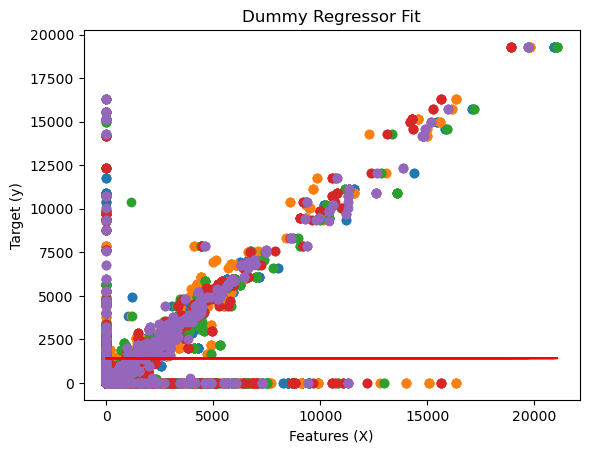

In [106]:
plt.plot(X, y, 'o', label='Data')
plt.plot(X, dummy_regr.predict(X), 'r-', label='Dummy Regressor')
plt.xlabel('Features (X)')
plt.ylabel('Target (y)')
plt.title('Dummy Regressor Fit');

In [102]:
dummy_regr.constant_

array([[1422.8399326]])

In [117]:
def evaluate_model(model, X, y):
    predictions = model.predict(X)
    rmse = root_mean_squared_error(y, predictions)
    mae = mean_absolute_error(y, predictions)

    print("Root Mean Squared Error:", rmse)
    print("Mean Absolute Error:", mae)
    return rmse, mae

In [118]:
evaluate_model(dummy_regr, X, y)

Root Mean Squared Error: 2841.8478857458117
Mean Absolute Error: 1776.8526049898899


(2841.8478857458117, 1776.8526049898899)

baseline model is super bad, which is good

> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?


### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [119]:
lin_reg = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg.fit(X_train, y_train)

pred = lin_reg.predict(X_test)

evaluate_model(lin_reg, X_test, y_test)

Root Mean Squared Error: 1709.8641349279294
Mean Absolute Error: 836.5275396067793


(1709.8641349279294, 836.5275396067793)

In [123]:
lin_reg.intercept_

7.451251082585031

In [122]:
lin_reg.coef_

array([ 0.01759409,  0.19816405, -0.05938529,  0.32933833,  0.45015506])

> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?


for predicting year 2024, coefficient with 2023 is positively related: this can be interpreted as, an increase in production in 2023 is followed by increase in production in 2024
on the other side, production in 2020 is negatively correlated with the production output

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [126]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error"}

results = {}
for name, model in [("lin_reg", lin_reg), ("dummy_reg", dummy_regr)]:
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    results[name] = {
        "R2 mean": scores["test_r2"].mean(),
        "R2 std": scores["test_r2"].std(),
        "RMSE mean": -scores["test_rmse"].mean(),
        "RMSE std": scores["test_rmse"].std(),
    }

print(pd.DataFrame(results).T.round(3))

           R2 mean  R2 std  RMSE mean  RMSE std
lin_reg      0.623   0.091   1716.856   160.742
dummy_reg   -0.002   0.002   2836.162   196.949


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?


Linear regression shows only a weak (R^2 =0.6) quality of the model, and it has a dissapointingly high RMSE error. not a good model

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

y_pred_ridge = ridge_reg.predict(X_test)

RF_reg = RandomForestRegressor(n_estimators=100, random_state=42)
RF_reg.fit(X_train, y_train)

y_pred_RF = RF_reg.predict(X_test)

> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?


### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?


## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?


### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?


### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?


## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?


- it was challenging to think how to improve models once you are not satisfied with their performance. But mainly, I am not struggling with the pipeline itslef, it is a pretty straightforward set of tasks that i am familiar with. But its confusing on how to divide tasks in such pipeline, since every next step depends on the previous, so steps cannot be worked on in parallel